In [1]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

'export' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import os
os.chdir('D:/thesis_code/keypoint_matcher')

import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import math


# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

In [ ]:
from PIL import ImageDraw

def draw_circle(image, x, y, radius=5, color="red"):
    draw = ImageDraw.Draw(image)
    draw.ellipse((x - radius, y - radius, x + radius, y + radius), outline=color, width=2)
    return image


def draw_square(image, x, y, size=10, color="blue"):
    draw = ImageDraw.Draw(image)
    half = size // 2
    draw.rectangle((x - half, y - half, x + half, y + half), outline=color, width=2)
    return image

In [5]:
df = pd.read_csv(
    "training.csv",
    header=0,
    names=(
        "dataset",
        "cam",
        "kpid",
        "pair_name",
        "x0", "y0",
        "x1", "y1",
        "x_guess", "y_guess",
        "certainty",
    )
)

,dataset,cam,kpid,pair_name,x0,y0,x1,y1,x_guess,y_guess,certainty
0,MOO11_short_3_backandforth,0,1.0,8989014683290_8989047971790,161.536392,290.211517,161.276184,290.524109,161.528809,290.178772,0.587604
1,MOO11_short_3_backandforth,0,61.0,8989047971790_8989081263190,328.199493,72.053383,328.310486,72.946960,328.196564,72.025696,0.159777
2,MOO11_short_3_backandforth,0,63.0,8989114550790_8989147840590,473.058411,274.744171,473.134338,274.571686,473.051544,274.750977,0.985908
3,MOO11_short_3_backandforth,0,70.0,8989114550790_8989147840590,209.226028,122.872673,209.637497,122.533905,209.211838,122.869713,0.444692
4,MOO11_short_3_backandforth,0,71.0,8989114550790_8989147840590,238.873779,200.832397,238.450012,200.493927,238.858780,200.831268,0.948312


In [161]:
random_row = df.iloc[60, :].values

[
    DATASET,
    cam,
    kpid,
    pair_name,
    x0, y0,
    x1, y1,
    x_guess, y_guess,
    certainty
] = random_row

x0, y0, x1, y1, x_guess, y_guess = round(x0, 2), round(y0, 2), round(x1, 2), round(y1, 2), round(x_guess, 2), round(y_guess, 2)

ref_keypoint = (x0, y0)
tar_keypoint = (x1, y1)
guess_keypoint = (x_guess, y_guess)

In [162]:
left_name = pair_name.split("_")[0]
right_name = pair_name.split("_")[1]

image_a_path = f"D:/thesis_code/datasets/monado_slam/{DATASET}/mav0/cam{cam}/data/{left_name}.png"
image_b_path = f"D:/thesis_code/datasets/monado_slam/{DATASET}/mav0/cam{cam}/data/{right_name}.png"

In [163]:
def get_patch_boundary(image: Image.Image, center_point, patch_size):
    image_width, image_height = image.size
    x, y = center_point
    half_patch_size = patch_size // 2

    # Convert to integers to avoid floating-point issues
    x, y = int(round(x)), int(round(y))

    left = max(0, min(math.floor(x - half_patch_size), image_width - patch_size))
    upper = max(0, min(math.floor(y - half_patch_size), image_height - patch_size))

    right, lower = left + patch_size, upper + patch_size

    print(f'Left: {left}, Right: {right}, Upper: {upper}, Lower: {lower}')

    assert right > left, f'Left: {left}, Right: {right}'
    assert right - left == patch_size, f'Right - Left: {right - left}'
    assert lower > upper, f'Upper: {upper}, Lower: {lower}'
    assert lower - upper == patch_size, f'Lower - Upper: {lower - upper}'

    return left, upper, right, lower

Image size: (640, 480)
Keypoint: (359.23, 172.57)
Left: 295, Right: 423, Upper: 109, Lower: 237
New keypoint: (64.23000000000002, 63.56999999999999)


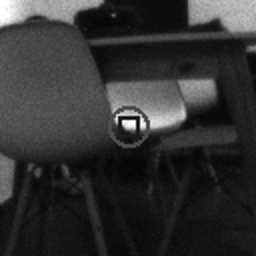

In [164]:
def prepare_target_patch(image_path, keypoint):
    mode = 'L' # 'RGB'
    image = Image.open(image_path).convert(mode)
    print(f'Image size: {image.size}')

    patch_size = 128

    print(f'Keypoint: {keypoint}')
    x0, y0 = keypoint
    image = draw_circle(image, x0, y0, radius=10, color="red")

    left, upper, right, lower = get_patch_boundary(image, keypoint, patch_size)

    patch = image.crop((left, upper, right, lower))
    assert patch.size == (patch_size, patch_size), f'Crop patch size mismatch: {patch.size}'

    new_keypoint = x0 - left, y0 - upper
    patch = draw_square(patch, new_keypoint[0], new_keypoint[1], size=10, color="blue")
    print(f'New keypoint: {new_keypoint}')

    return patch, new_keypoint


patch, new_keypoint = prepare_target_patch(image_a_path, ref_keypoint)
patch.resize((256, 256))

Left: 269, Right: 397, Upper: 129, Lower: 257


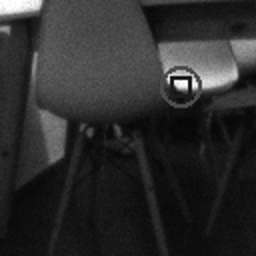

In [165]:
def prepare_jitter_reference_patch(image_path, old_keypoint, patch_size=128, mode='L'):
    image = Image.open(image_path).convert(mode)

    x0, y0 = old_keypoint
    image = draw_circle(image, x0, y0, radius=10, color="red")

    # Define max perturbation to keep old keypoint inside
    padding = 25

    max_perturb_x =  max(0, min(
        patch_size // 2 - 1 - padding,
        x0 - padding,
        image.width - x0 - 1 - padding
    ))

    max_perturb_y = max(0, min(
        patch_size // 2 - 1 - padding,
        y0 - padding,
        image.height - y0 - 1 - padding
    ))

    perturb_x = np.random.randint(-max_perturb_x, max_perturb_x + 1)
    perturb_y = np.random.randint(-max_perturb_y, max_perturb_y + 1)

    new_x, new_y = x0 + perturb_x, y0 + perturb_y

    # Crop centered at the new keypoint
    left, upper, right, lower = get_patch_boundary(image, (new_x, new_y), patch_size)
    patch = image.crop((left, upper, right, lower))

    # Convert old keypoint to patch coordinates
    old_keypoint = (x0 - left, y0 - upper)

    patch = draw_square(patch, old_keypoint[0], old_keypoint[1], size=10, color="blue")

    return patch, old_keypoint


patch, new_keypoint = prepare_jitter_reference_patch(image_a_path, ref_keypoint)
patch.resize((256, 256))

Left: 277, Right: 405, Upper: 151, Lower: 279


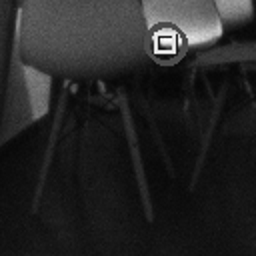

In [166]:
def prepare_jitter_target_patch(
        image_path, keypoint1, keypoint2, patch_size=128, mode='L'
):
    image = Image.open(image_path).convert(mode)

    x0, y0 = keypoint1
    x1, y1 = keypoint2

    image = draw_circle(image, x0, y0, radius=10, color="red")
    image = draw_circle(image, x1, y1, radius=10, color="green")

    # Define max perturbation ensuring both keypoints stay in bounds
    padding = 20

    max_perturb_x =  max(0, min(
        patch_size // 2 - 1 - padding,
        x0 - padding, image.width - x0 - 1 - padding,
        x1 - padding, image.width - x1 - 1 - padding
    ))

    max_perturb_y =  max(0, min(
        patch_size // 2 - 1 - padding,
        y0 - padding, image.height - y0 - 1 - padding,
        y1 - padding, image.height - y1 - 1 - padding
    ))

    perturb_x = np.random.randint(-max_perturb_x, max_perturb_x + 1)
    perturb_y = np.random.randint(-max_perturb_y, max_perturb_y + 1)

    new_x, new_y = (x0 + x1) // 2 + perturb_x, (y0 + y1) // 2 + perturb_y  # Center between keypoints

    # Crop centered at the new position
    left, upper, right, lower = get_patch_boundary(image, (new_x, new_y), patch_size)
    patch = image.crop((left, upper, right, lower))

    # Convert keypoints to patch coordinates
    keypoint1_patch = (x0 - left, y0 - upper)
    keypoint2_patch = (x1 - left, y1 - upper)

    patch = draw_square(
        patch, keypoint1_patch[0], keypoint1_patch[1], size=10, color="blue"
    )

    patch = draw_square(
        patch, keypoint2_patch[0], keypoint2_patch[1], size=10, color="yellow"
    )

    return patch, keypoint1_patch, keypoint2_patch


patch, keypoint1_patch, keypoint2_patch = prepare_jitter_target_patch(
    image_a_path, tar_keypoint, guess_keypoint
)

patch.resize((256, 256))

In [167]:
from src import RoPENd

patch_size = 128

pe = RoPENd((patch_size, patch_size, 240))
t = torch.randn(16, patch_size, patch_size, 240)
pe_t = pe(t)